# 04 - Evaluation and Explainability: APTOS 2019 DR Grading

Final stage of the pipeline. Reloads the best validation-QWK EfficientNet-B3 checkpoint from
`03_model_training`, evaluates it once on the untouched test split, and provides the test metrics, confusion matrices and error analysis for the report. Grad-CAM explainability is in .

**Consumes** (from earlier stages)
- `artifacts/preprocessing/aptos_preprocessed_384_manifest.csv` - split, labels, image paths.
- `artifacts/checkpoints/efficientnet_b3_best_qwk.pt` - trained model + metadata.

**Produces**
- `artifacts/results/test_metrics.csv`, `test_metrics.json` - headline metrics with bootstrap CIs.
- `artifacts/results/test_predictions.csv`, `classification_report.csv`.
- `studies/04_evaluation/figures/*.png` - confusion matrices, error distribution, Grad-CAM panel.

Test-set discipline: the test split is evaluated exactly once, after model selection on validation.
No thresholds or hyperparameters are tuned here.

## 0. Setup

Paths resolve automatically whether the artifacts are in the current Kaggle session
(`/kaggle/working`), attached from a previous run under `/kaggle/input/...`, or in a local
checkout. Outputs are written to the working directory.

In [1]:
# Version record for reproducibility.
import sys, platform
import numpy as np, pandas as pd, torch, torchvision, sklearn
print("python      ", platform.python_version())
for m in (np, pd, torch, torchvision, sklearn):
    print(f"{m.__name__:<12}", m.__version__)

python       3.11.15
numpy        2.4.4
pandas       3.0.3
torch        2.13.0+cu126
torchvision  0.28.0+cu126
sklearn      1.9.0


In [2]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             precision_score, recall_score, cohen_kappa_score,
                             confusion_matrix, classification_report, roc_auc_score)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

ID_COL, LABEL_COL = "id_code", "diagnosis"
CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]
MINORITY = [1, 3, 4]                 # Mild, Severe, Proliferative
IMG_SIZE, BATCH_SIZE, NUM_WORKERS = 384, 8, 0

MANIFEST_REL   = f"artifacts/preprocessing/aptos_preprocessed_{IMG_SIZE}_manifest.csv"
CHECKPOINT_REL = "artifacts/checkpoints/efficientnet_b3_best_qwk.pt"

def resolve(rel):
    """Find an artifact across Kaggle working, attached inputs, or local checkout."""
    roots = [Path("/kaggle/working"), Path(".")]
    inp = Path("/kaggle/input")
    if inp.exists():
        roots += sorted(inp.iterdir())
    for r in roots:
        if (r / rel).exists():
            return r / rel
    raise FileNotFoundError(f"Could not locate {rel}. Run stages 01-03 first, or attach their output.")

MANIFEST_PATH   = resolve(MANIFEST_REL)
CHECKPOINT_PATH = resolve(CHECKPOINT_REL)

OUTPUT_BASE = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
RESULTS_DIR = OUTPUT_BASE / "artifacts/results"
FIGURE_DIR  = OUTPUT_BASE / "studies/04_evaluation/figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device        :", device)
print("Manifest      :", MANIFEST_PATH)
print("Checkpoint    :", CHECKPOINT_PATH)

Device        : cuda
Manifest      : artifacts\preprocessing\aptos_preprocessed_384_manifest.csv
Checkpoint    : artifacts\checkpoints\efficientnet_b3_best_qwk.pt


## 1. Load the untouched test split

In [3]:
manifest_df = pd.read_csv(MANIFEST_PATH)
test_df = manifest_df[manifest_df["split"] == "test"].reset_index(drop=True)
print("Test images:", len(test_df))
display(test_df[LABEL_COL].value_counts().sort_index()
        .rename(index={i: CLASS_NAMES[i] for i in range(5)}).to_frame("count"))

Test images: 550


,count
diagnosis,
No DR,271
Mild,56
Moderate,150
Severe,29
Proliferative,44


## 2. Test dataset and loader

Images are already cropped, CLAHE-enhanced and resized to 384 in preprocessing, so only tensor
conversion and ImageNet normalisation are applied. No augmentation.

In [4]:
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class APTOSDataset(Dataset):
    def __init__(self, frame, transform):
        self.df, self.transform = frame.reset_index(drop=True), transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row["preprocessed_path"]).convert("RGB")
        return self.transform(img), int(row[LABEL_COL]), row[ID_COL], row["preprocessed_path"]

test_dataset = APTOSDataset(test_df, eval_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

_img, _, _, _ = test_dataset[0]
assert tuple(_img.shape) == (3, IMG_SIZE, IMG_SIZE), f"Unexpected image shape {_img.shape}"
print("Test loader ready.")

Test loader ready.


## 3. Reload the trained model

The architecture is rebuilt to match `03` (EfficientNet-B3, dropout 0.35, 5-class head) and the
saved weights are loaded.

In [5]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

model = models.efficientnet_b3(weights=None)
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(nn.Dropout(p=0.35, inplace=True), nn.Linear(in_features, 5))
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device).eval()

val_qwk_at_selection = checkpoint.get("best_val_qwk")
print("Loaded checkpoint. Best validation QWK at selection:", round(val_qwk_at_selection, 4)
      if val_qwk_at_selection is not None else "n/a")

Loaded checkpoint. Best validation QWK at selection: 0.8579


## 4. Test predictions and probabilities

In [6]:
y_true, y_pred, y_prob, ids, paths = [], [], [], [], []
with torch.no_grad():
    for images, labels, image_ids, image_paths in test_loader:
        probs = torch.softmax(model(images.to(device)), dim=1)
        y_true.extend(labels.tolist())
        y_pred.extend(probs.argmax(1).cpu().tolist())
        y_prob.extend(probs.cpu().tolist())
        ids.extend(list(image_ids)); paths.extend(list(image_paths))

y_true, y_pred, y_prob = np.array(y_true), np.array(y_pred), np.array(y_prob)

predictions_df = pd.DataFrame({ID_COL: ids, "image_path": paths,
                               "true_grade": y_true, "predicted_grade": y_pred,
                               "confidence": y_prob.max(1), "correct": y_true == y_pred})
for c, name in enumerate(CLASS_NAMES):
    predictions_df[f"prob_{c}_{name.replace(' ', '_')}"] = y_prob[:, c]
predictions_df.to_csv(RESULTS_DIR / "test_predictions.csv", index=False)
print("Predictions saved:", RESULTS_DIR / "test_predictions.csv")
display(predictions_df.head())

Predictions saved: artifacts\results\test_predictions.csv


,id_code,image_path,true_grade,predicted_grade,confidence,correct,prob_0_No_DR,prob_1_Mild,prob_2_Moderate,prob_3_Severe,prob_4_Proliferative
0,005b95c28852,data\preprocessed_384\005b95c28852.png,0,0,0.882242,True,0.882242,0.040023,0.025119,0.037396,0.015220
1,00f6c1be5a33,data\preprocessed_384\00f6c1be5a33.png,0,0,0.929028,True,0.929028,0.014020,0.014847,0.021355,0.020751
2,0104b032c141,data\preprocessed_384\0104b032c141.png,3,3,0.556658,True,0.010355,0.023316,0.392867,0.556658,0.016804
3,0124dffecf29,data\preprocessed_384\0124dffecf29.png,1,1,0.798386,True,0.098777,0.798386,0.089647,0.006441,0.006749
4,0180bfa26c0b,data\preprocessed_384\0180bfa26c0b.png,2,2,0.505649,True,0.001031,0.069631,0.505649,0.056896,0.366793


## 5. Overall test metrics with bootstrap confidence intervals

QWK is the primary metric for this ordinal task. 95% confidence intervals are estimated by
bootstrap resampling the test set (1000 resamples), so the headline numbers carry uncertainty
rather than being reported as point estimates.

In [7]:
def qwk(a, b):      return cohen_kappa_score(a, b, weights="quadratic")
def macro_f1(a, b): return f1_score(a, b, average="macro", zero_division=0)

metrics = {
    "accuracy":          accuracy_score(y_true, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    "macro_f1":          macro_f1(y_true, y_pred),
    "weighted_f1":       f1_score(y_true, y_pred, average="weighted", zero_division=0),
    "macro_precision":   precision_score(y_true, y_pred, average="macro", zero_division=0),
    "macro_recall":      recall_score(y_true, y_pred, average="macro", zero_division=0),
    "qwk":               qwk(y_true, y_pred),
}
per_class_recall = recall_score(y_true, y_pred, average=None, labels=range(5), zero_division=0)
metrics["minority_mean_recall"] = float(np.mean([per_class_recall[i] for i in MINORITY]))
try:
    metrics["macro_roc_auc_ovr"] = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
except ValueError:
    metrics["macro_roc_auc_ovr"] = float("nan")

# Bootstrap 95% CIs for the key metrics.
rng = np.random.default_rng(SEED)
idx = np.arange(len(y_true))
boot = {"qwk": [], "accuracy": [], "macro_f1": []}
for _ in range(1000):
    s = rng.choice(idx, size=len(idx), replace=True)
    boot["qwk"].append(qwk(y_true[s], y_pred[s]))
    boot["accuracy"].append(accuracy_score(y_true[s], y_pred[s]))
    boot["macro_f1"].append(macro_f1(y_true[s], y_pred[s]))
ci = {k: (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))) for k, v in boot.items()}

rows = []
for k, v in metrics.items():
    lo, hi = ci.get(k, (None, None))
    rows.append({"metric": k, "value": round(float(v), 4),
                 "ci_low": None if lo is None else round(lo, 4),
                 "ci_high": None if hi is None else round(hi, 4)})
metrics_df = pd.DataFrame(rows)
display(metrics_df)

metrics_df.to_csv(RESULTS_DIR / "test_metrics.csv", index=False)
with open(RESULTS_DIR / "test_metrics.json", "w") as f:
    json.dump({"point": {k: float(v) for k, v in metrics.items()},
               "ci95": ci, "val_qwk_at_selection": val_qwk_at_selection}, f, indent=2)
print(f"Test QWK = {metrics['qwk']:.4f}  (95% CI {ci['qwk'][0]:.4f} to {ci['qwk'][1]:.4f})")

,metric,value,ci_low,ci_high
0,accuracy,0.8036,0.7709,0.8364
1,balanced_accuracy,0.6565,NaN,NaN
2,macro_f1,0.6487,0.5930,0.6984
3,weighted_f1,0.8054,NaN,NaN
4,macro_precision,0.6465,NaN,NaN
5,macro_recall,0.6565,NaN,NaN
6,qwk,0.8741,0.8361,0.9094
7,minority_mean_recall,0.5361,NaN,NaN
8,macro_roc_auc_ovr,0.9030,NaN,NaN


Test QWK = 0.8741  (95% CI 0.8361 to 0.9094)


## 6. Per-class classification report

Strong overall accuracy can hide weak recall on the minority grades (Mild, Severe, Proliferative),
which are the clinically important cases. The per-class breakdown makes that visible.

In [8]:
report = classification_report(y_true, y_pred, labels=range(5), target_names=CLASS_NAMES,
                               output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
display(report_df.round(4))
report_df.to_csv(RESULTS_DIR / "classification_report.csv")

,precision,recall,f1-score,support
No DR,0.9565,0.9742,0.9653,271.0000
Mild,0.5139,0.6607,0.5781,56.0000
Moderate,0.8140,0.7000,0.7527,150.0000
Severe,0.3667,0.3793,0.3729,29.0000
Proliferative,0.5814,0.5682,0.5747,44.0000
accuracy,0.8036,0.8036,0.8036,0.8036
macro avg,0.6465,0.6565,0.6487,550.0000
weighted avg,0.8115,0.8036,0.8054,550.0000


## 7. Confusion matrices

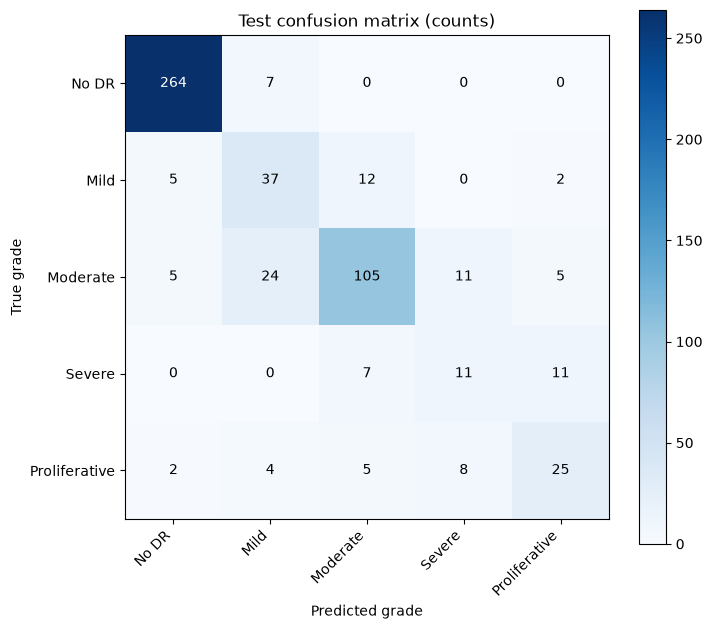

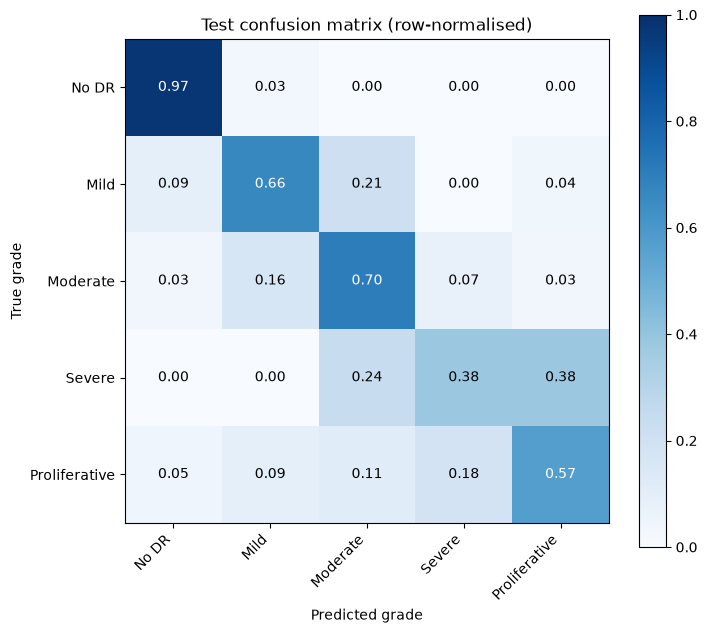

In [9]:
def plot_cm(cm, title, fname, fmt):
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues",
                   vmin=0, vmax=1 if fmt == "{:.2f}" else None)
    ax.figure.colorbar(im, ax=ax)
    ticks = np.arange(len(CLASS_NAMES))
    ax.set(xticks=ticks, yticks=ticks, xlabel="Predicted grade", ylabel="True grade", title=title)
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    thr = (cm.max() if fmt != "{:.2f}" else 1.0) / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, fmt.format(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > thr else "black")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / fname, dpi=180, bbox_inches="tight")
    plt.show()

cm = confusion_matrix(y_true, y_pred, labels=range(5))
plot_cm(cm, "Test confusion matrix (counts)", "confusion_matrix_counts.png", "{:d}")
cm_norm = confusion_matrix(y_true, y_pred, labels=range(5), normalize="true")
plot_cm(cm_norm, "Test confusion matrix (row-normalised)", "confusion_matrix_normalized.png", "{:.2f}")

## 8. Ordinal error-distance analysis

DR grades are ordered, so the size of an error matters: predicting grade 3 for a grade 4 is a near
miss, while predicting grade 0 for a grade 4 is a clinically serious error. This section quantifies
how far off the model is when it is wrong.

,count
absolute_grade_error,
0,442
1,85
2,15
3,6
4,2


Mean absolute grade error : 0.2564
Within one grade          : 0.9582
Errors that are adjacent   : 85/108 (78.7%)
Errors that are distant >=2: 23/108 (21.3%)


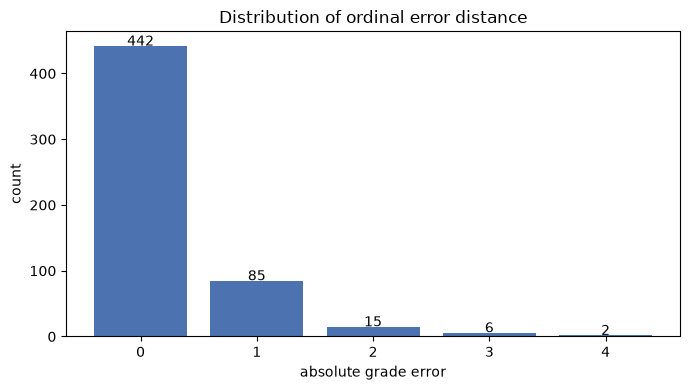

In [10]:
grade_error = np.abs(y_true - y_pred)
dist = pd.Series(grade_error).value_counts().sort_index()
dist.index.name = "absolute_grade_error"; dist.name = "count"
display(dist.to_frame())

n_err = int((grade_error > 0).sum())
adjacent = int((grade_error == 1).sum())
distant  = int((grade_error >= 2).sum())
mae = float(grade_error.mean())
print(f"Mean absolute grade error : {mae:.4f}")
print(f"Within one grade          : {np.mean(grade_error <= 1):.4f}")
print(f"Errors that are adjacent   : {adjacent}/{n_err} ({(adjacent / n_err if n_err else 0):.1%})")
print(f"Errors that are distant >=2: {distant}/{n_err} ({(distant / n_err if n_err else 0):.1%})")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dist.index.astype(int), dist.values, color="#4C72B0")
ax.set(xlabel="absolute grade error", ylabel="count", title="Distribution of ordinal error distance")
for x, v in zip(dist.index.astype(int), dist.values):
    ax.text(x, v + 0.5, str(v), ha="center")
plt.tight_layout(); plt.savefig(FIGURE_DIR / "error_distance.png", dpi=180, bbox_inches="tight"); plt.show()

## 9. Most confident mistakes

High-confidence errors are the most useful cases for qualitative review: they surface possible label
ambiguity and are natural candidates for Grad-CAM inspection.

In [11]:
mistakes_df = predictions_df[~predictions_df["correct"]].sort_values("confidence", ascending=False)
display(mistakes_df[[ID_COL, "true_grade", "predicted_grade", "confidence", "image_path"]].head(10))

,id_code,true_grade,predicted_grade,confidence,image_path
377,b019a49787c1,3,4,0.997608,data\preprocessed_384\b019a49787c1.png
376,af3b0115aad1,3,4,0.997450,data\preprocessed_384\af3b0115aad1.png
480,e1fb532f55df,3,4,0.996849,data\preprocessed_384\e1fb532f55df.png
105,3435fd8675a2,3,4,0.981523,data\preprocessed_384\3435fd8675a2.png
56,19244004583f,3,4,0.962073,data\preprocessed_384\19244004583f.png
522,f5e6226bd2e0,4,3,0.945617,data\preprocessed_384\f5e6226bd2e0.png
78,253e96488cfb,0,1,0.934514,data\preprocessed_384\253e96488cfb.png
275,82f2784ead76,2,3,0.933352,data\preprocessed_384\82f2784ead76.png
182,5b804948e35f,1,0,0.925142,data\preprocessed_384\5b804948e35f.png
449,d7e5fe5245e0,0,1,0.915273,data\preprocessed_384\d7e5fe5245e0.png


## 11. Reporting summary

The values below are computed from the results above and answer the core questions the report needs
to address: test performance versus the validation selection point, the weakest grade, the balance
of adjacent versus distant errors, and minority-grade recall.

In [12]:
recalls = {CLASS_NAMES[i]: float(per_class_recall[i]) for i in range(5)}
lowest_recall_class = min(recalls, key=recalls.get)

summary = {
    "test_qwk": round(float(metrics["qwk"]), 4),
    "test_qwk_ci95": [round(ci["qwk"][0], 4), round(ci["qwk"][1], 4)],
    "val_qwk_at_selection": None if val_qwk_at_selection is None else round(float(val_qwk_at_selection), 4),
    "test_macro_f1": round(float(metrics["macro_f1"]), 4),
    "test_balanced_accuracy": round(float(metrics["balanced_accuracy"]), 4),
    "test_accuracy": round(float(metrics["accuracy"]), 4),
    "minority_mean_recall": round(float(metrics["minority_mean_recall"]), 4),
    "lowest_recall_grade": lowest_recall_class,
    "lowest_recall_value": round(recalls[lowest_recall_class], 4),
    "adjacent_error_share": round(adjacent / n_err, 4) if n_err else None,
    "distant_error_share": round(distant / n_err, 4) if n_err else None,
    "mean_absolute_grade_error": round(mae, 4),
}
with open(RESULTS_DIR / "evaluation_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

{
  "test_qwk": 0.8741,
  "test_qwk_ci95": [
    0.8361,
    0.9094
  ],
  "val_qwk_at_selection": 0.8579,
  "test_macro_f1": 0.6487,
  "test_balanced_accuracy": 0.6565,
  "test_accuracy": 0.8036,
  "minority_mean_recall": 0.5361,
  "lowest_recall_grade": "Severe",
  "lowest_recall_value": 0.3793,
  "adjacent_error_share": 0.787,
  "distant_error_share": 0.213,
  "mean_absolute_grade_error": 0.2564
}


### Notes for the report

- Compare `test_qwk` with `val_qwk_at_selection`. A small gap indicates the model generalises rather
  than overfitting the validation split used for selection.
- `lowest_recall_grade` is the grade to discuss as the main weakness, and it typically coincides with
  the smallest class.
- A high `adjacent_error_share` relative to `distant_error_share` supports the claim that mistakes are
  mostly near-misses, which is the desirable failure mode for an ordinal clinical task.
- Explainability (Grad-CAM) is produced in , which reads the predictions
  file saved here to select the confident-mistake cases.

## Appendix - requirements.txt

Same pinned file as the earlier stages (repository root):

```
numpy==1.26.4
pandas==2.2.2
scikit-learn==1.4.2
matplotlib==3.8.4
torch==2.2.2
torchvision==0.17.2
pillow==10.3.0
```